<a href="https://colab.research.google.com/github/jennysaad/meliora/blob/develop/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/e')

Mounted at /content/drive


In [5]:
import os #testtestetstetst
print(os.listdir('/content/drive/MyDrive/training'))

['AD', 'FTD', 'CN', 'train_label_mapping.csv']


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# Load the label mapping
labels_df = pd.read_csv('/content/drive/MyDrive/training/train_label_mapping.csv')
print(labels_df.head(10))
print(labels_df['label'].value_counts())

   anonymized_id label
0              2     F
1              3     A
2              4     A
3              8     A
4              9     A
5             10     C
6             13     F
7             14     F
8             15     F
9             16     F
label
A    25
F    16
C    13
Name: count, dtype: int64


In [17]:
example = np.load('/content/drive/MyDrive/training/AD/3.npy')
print(f"Shape: {example.shape}")

Shape: (19, 119608)


In [18]:
task_labels = labels_df[labels_df['label'].isin(['A', 'C'])].copy()
task_labels['binary_label'] = task_labels['label'].map({'A': 1, 'C': 0})
print(task_labels['binary_label'].value_counts())

binary_label
1    25
0    13
Name: count, dtype: int64


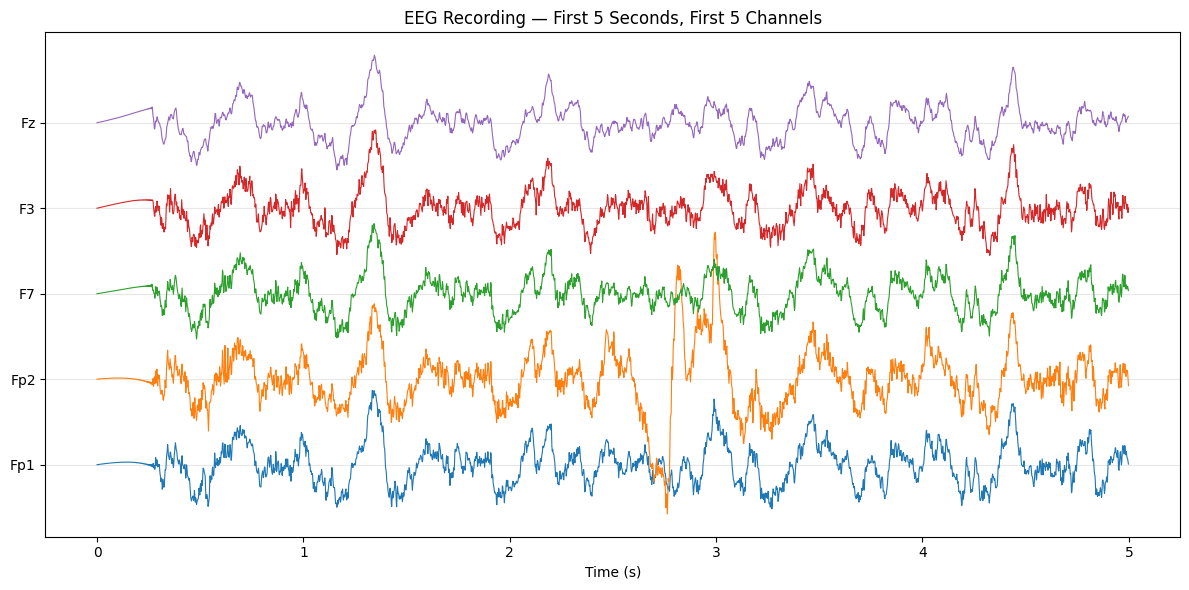

In [20]:
fs = 500 # sampling rate in Hz
duration = 5 # seconds to plot
max_samples = int(fs * duration)
data = example[:5, :max_samples] # first 5 channels, first 5 seconds
time = np.arange(max_samples) / fs
spacing = 100
scaling_factor = spacing / (np.std(data) * 4)
scaled_data = data * scaling_factor
channel_names = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz']
plt.figure(figsize=(12, 6))
offsets = np.arange(len(scaled_data)) * spacing
for i in range(len(scaled_data)):
  plt.plot(time, scaled_data[i] + offsets[i], linewidth=0.8)
plt.yticks(offsets, channel_names)
plt.xlabel('Time (s)')
plt.title('EEG Recording — First 5 Seconds, First 5 Channels')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
base = '/content/drive/MyDrive/training'

all_data = {}
for group in ['AD','CN']:
    folder = f'{base}/{group}'
    for fname in os.listdir(folder):
        if fname.endswith('.npy'):
            subject_id = int(fname.replace('.npy', ''))
            all_data[subject_id] = np.load(f'{folder}/{fname}', allow_pickle=True)
            print(f"Loaded subject {subject_id}: shape {all_data[subject_id].shape}")

print(f"\nTotal subjects loaded: {len(all_data)}")

Loaded subject 44: shape (19, 98102)
Loaded subject 86: shape (19, 147297)
Loaded subject 28: shape (19, 107694)
Loaded subject 61: shape (19, 70922)
Loaded subject 4: shape (19, 80947)
Loaded subject 56: shape (19, 76774)
Loaded subject 27: shape (19, 101555)
Loaded subject 9: shape (19, 106847)
Loaded subject 18: shape (19, 107277)
Loaded subject 3: shape (19, 119608)
Loaded subject 73: shape (19, 105206)
Loaded subject 70: shape (19, 90381)
Loaded subject 8: shape (19, 102116)
Loaded subject 50: shape (19, 94853)
Loaded subject 51: shape (19, 39181)
Loaded subject 76: shape (19, 102925)
Loaded subject 32: shape (19, 90294)
Loaded subject 53: shape (19, 101517)
Loaded subject 82: shape (19, 111270)
Loaded subject 78: shape (19, 105754)
Loaded subject 34: shape (19, 94295)
Loaded subject 55: shape (19, 124462)
Loaded subject 81: shape (19, 104722)
Loaded subject 40: shape (19, 164060)
Loaded subject 46: shape (19, 117796)
Loaded subject 74: shape (19, 89490)
Loaded subject 14: shape (